<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/monthly_milk_production (1).csv')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

# Get basic information about the dataset
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

First 5 rows of the dataset:


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB

Missing values in each column:
Date          0
Production    0
dtype: int64


From the `df.info()` output, we can see that the `Month` column is currently an object type. For time series analysis, it's crucial to convert it to a datetime object. The `Production` column (which seems to represent milk production) is already a float, which is suitable for numerical analysis.

In [4]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index for time series analysis
df.set_index('Date', inplace=True)

# Display the updated DataFrame info and head to confirm changes
print("\nDataset Information after converting 'Date' to datetime and setting as index:")
df.info()
print("\nFirst 5 rows after setting 'Date' as index:")
display(df.head())


Dataset Information after converting 'Date' to datetime and setting as index:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB

First 5 rows after setting 'Date' as index:


,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


Now that the data is properly formatted with a datetime index, let's visualize the milk production over time to observe trends, seasonality, and any potential anomalies.

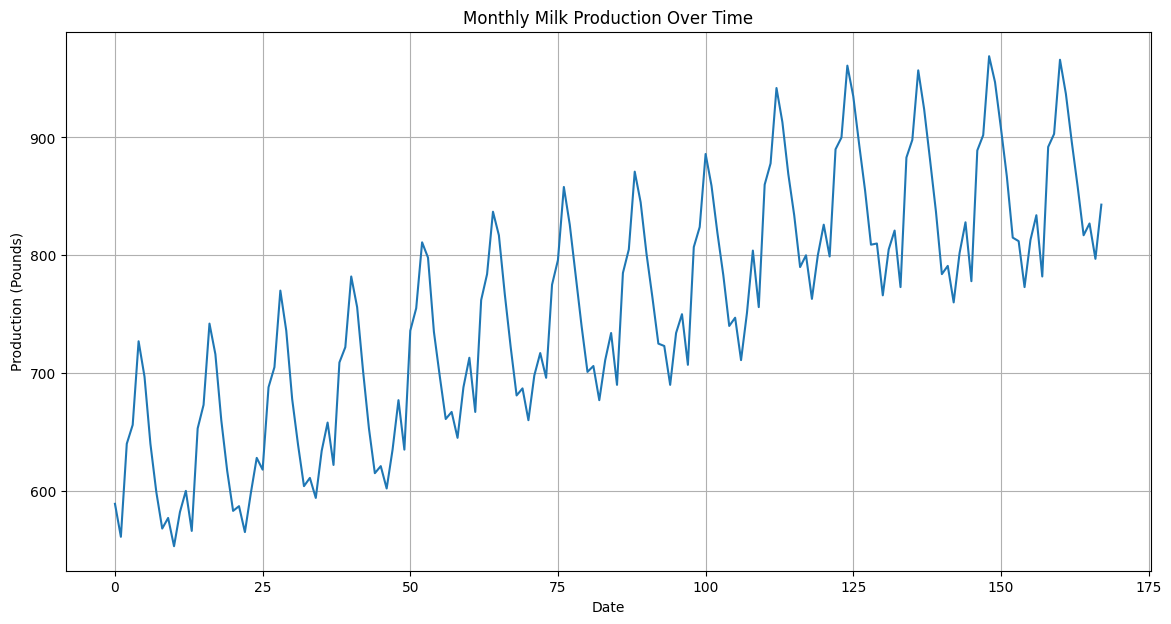

In [3]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x=df.index, y='Production')
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production (Pounds)')
plt.grid(True)
plt.show()

### EDA Summary

The visualization clearly shows an upward trend in milk production over the years, indicating growth. We can also observe a strong seasonal pattern, with production peaking during certain months and dipping in others. There were no missing values identified in the dataset. Before proceeding to model building, it's a good practice to normalize or scale the data, especially for neural network models, to help with convergence and performance.

### Normalizing/Scaling the Data

Neural networks often perform better when input features are scaled to a similar range. We will use `MinMaxScaler` from `sklearn.preprocessing` to scale the 'Production' data to a range between 0 and 1.

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape the data for scaling (MinMaxScaler expects 2D array)
production_data = df['Production'].values.reshape(-1, 1)

# Scale the 'Production' data
scaled_production_data = scaler.fit_transform(production_data)

# Create a new DataFrame or update the existing one with scaled data
df['Production_Scaled'] = scaled_production_data

print("First 5 rows of DataFrame with scaled production data:")
display(df.head())

print("\nDescriptive statistics of scaled production data:")
print(df['Production_Scaled'].describe())

First 5 rows of DataFrame with scaled production data:


,Production,Production_Scaled
Date,,
1962-01-01,589,0.086538
1962-02-01,561,0.019231
1962-03-01,640,0.209135
1962-04-01,656,0.247596
1962-05-01,727,0.418269



Descriptive statistics of scaled production data:
count    168.000000
mean       0.484876
std        0.245684
min        0.000000
25%        0.299880
50%        0.500000
75%        0.652644
max        1.000000
Name: Production_Scaled, dtype: float64


### Step 2: Data Preparation for Deep Learning

For recurrent neural networks (RNNs), such as LSTMs and GRUs, we need to structure our time series data into sequences. Each sequence will consist of a 'look_back' number of previous time steps (input) to predict the next time step (output). We will also split the data into training, validation, and test sets, and then reshape it to fit the input requirements of these models.

In [6]:
import numpy as np

# Function to create sequences for time series forecasting
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

# Define the look_back period (e.g., use the previous 12 months to predict the next month)
look_back = 12

# Prepare the scaled data for sequence creation
data_for_sequences = df['Production_Scaled'].values.reshape(-1, 1)

# Create sequences
X, y = create_sequences(data_for_sequences, look_back)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (output values): {y.shape}")

# Display first few input sequences and corresponding output
print("\nFirst 5 input sequences (X) and corresponding output (y):")
for i in range(5):
    print(f"X[{i}]: {X[i]}, y[{i}]: {y[i]}")

Shape of X (input sequences): (156, 12)
Shape of y (output values): (156,)

First 5 input sequences (X) and corresponding output (y):
X[0]: [0.08653846 0.01923077 0.20913462 0.24759615 0.41826923 0.34615385
 0.20913462 0.11057692 0.03605769 0.05769231 0.         0.06971154], y[0]: 0.11298076923076916
X[1]: [0.01923077 0.20913462 0.24759615 0.41826923 0.34615385 0.20913462
 0.11057692 0.03605769 0.05769231 0.         0.06971154 0.11298077], y[1]: 0.03125
X[2]: [0.20913462 0.24759615 0.41826923 0.34615385 0.20913462 0.11057692
 0.03605769 0.05769231 0.         0.06971154 0.11298077 0.03125   ], y[2]: 0.24038461538461542
X[3]: [0.24759615 0.41826923 0.34615385 0.20913462 0.11057692 0.03605769
 0.05769231 0.         0.06971154 0.11298077 0.03125    0.24038462], y[3]: 0.28846153846153855
X[4]: [0.41826923 0.34615385 0.20913462 0.11057692 0.03605769 0.05769231
 0.         0.06971154 0.11298077 0.03125    0.24038462 0.28846154], y[4]: 0.45432692307692313


In [7]:
# Split data into training, validation, and test sets
# We'll use an 80/10/10 split approximately, maintaining the time order.

train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)
test_size = len(X) - train_size - val_size

X_train, y_train = X[0:train_size], y[0:train_size]
X_val, y_val = X[train_size:(train_size + val_size)], y[train_size:(train_size + val_size)]
X_test, y_test = X[(train_size + val_size):len(X)], y[(train_size + val_size):len(X)]

print(f"\nTrain set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

# Reshape input to be 3D [samples, time steps, features] for Keras/TensorFlow models
# Our current X is [samples, look_back], so we add a feature dimension of 1.
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"\nReshaped X_train shape: {X_train.shape}")
print(f"Reshaped X_val shape: {X_val.shape}")
print(f"Reshaped X_test shape: {X_test.shape}")


Train set size: 124 samples
Validation set size: 15 samples
Test set size: 17 samples

Reshaped X_train shape: (124, 12, 1)
Reshaped X_val shape: (15, 12, 1)
Reshaped X_test shape: (17, 12, 1)


### Step 3: Model Building

Now we will build and compile three different recurrent neural network models: a Basic RNN, an LSTM, and a GRU. For each model, we'll define its architecture, compile it with a suitable optimizer and loss function, and then review its summary.

#### Basic RNN Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# Build the Basic RNN model
rnn_model = Sequential([
    Input(shape=(look_back, 1)), # Recommended way to specify input shape
    SimpleRNN(units=50, activation='relu'),
    Dense(units=1)
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
print("Basic RNN Model Summary:")
rnn_model.summary()

Basic RNN Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

#### LSTM Model

In [12]:
from tensorflow.keras.layers import LSTM, Input

# Build the LSTM model
lstm_model = Sequential([
    Input(shape=(look_back, 1)), # Recommended way to specify input shape
    LSTM(units=50, activation='relu'),
    Dense(units=1)
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
print("LSTM Model Summary:")
lstm_model.summary()

LSTM Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

#### GRU Model

In [13]:
from tensorflow.keras.layers import GRU, Input

# Build the GRU model
gru_model = Sequential([
    Input(shape=(look_back, 1)), # Recommended way to specify input shape
    GRU(units=50, activation='relu'),
    Dense(units=1)
])

# Compile the model
gru_model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
print("GRU Model Summary:")
gru_model.summary()

GRU Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Model Training

#### Evaluate LSTM Model

In [21]:
# Make predictions on the test set
lstm_test_predict = lstm_model.predict(X_test)

# Inverse transform the predictions to original scale
lstm_test_predict = scaler.inverse_transform(lstm_test_predict)

# Calculate RMSE
lstm_rmse = np.sqrt(mean_squared_error(y_test_inverse, lstm_test_predict))
print(f"LSTM Test RMSE: {lstm_rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
LSTM Test RMSE: 21.27


#### Evaluate GRU Model

In [22]:
# Make predictions on the test set
gru_test_predict = gru_model.predict(X_test)

# Inverse transform the predictions to original scale
gru_test_predict = scaler.inverse_transform(gru_test_predict)

# Calculate RMSE
gru_rmse = np.sqrt(mean_squared_error(y_test_inverse, gru_test_predict))
print(f"GRU Test RMSE: {gru_rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
GRU Test RMSE: 24.33


### Step 6: Model Comparison and Visualization

Now that we have evaluated all three models using RMSE, let's compare their performance and visualize their predictions against the actual values on the test set. We will also calculate other metrics like Mean Absolute Error (MAE) for a more comprehensive comparison.

In [26]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for Basic RNN
rnn_mae = mean_absolute_error(y_test_inverse, rnn_test_predict)
print(f"Basic RNN Test MAE: {rnn_mae:.2f}")

# Calculate MAE for LSTM
lstm_mae = mean_absolute_error(y_test_inverse, lstm_test_predict)
print(f"LSTM Test MAE: {lstm_mae:.2f}")

# Calculate MAE for GRU
gru_mae = mean_absolute_error(y_test_inverse, gru_test_predict)
print(f"GRU Test MAE: {gru_mae:.2f}")

# Create a DataFrame to compare results
results_df = pd.DataFrame({
    'Model': ['Basic RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae]
})

print("\nModel Performance Comparison:")
display(results_df.sort_values(by='RMSE'))

Basic RNN Test MAE: 9.30
LSTM Test MAE: 18.03
GRU Test MAE: 18.58

Model Performance Comparison:


,Model,RMSE,MAE
0,Basic RNN,11.616519,9.302681
1,LSTM,21.273959,18.031853
2,GRU,24.327407,18.583177


Let's visualize the predictions of each model against the actual test values to get a better understanding of their performance.

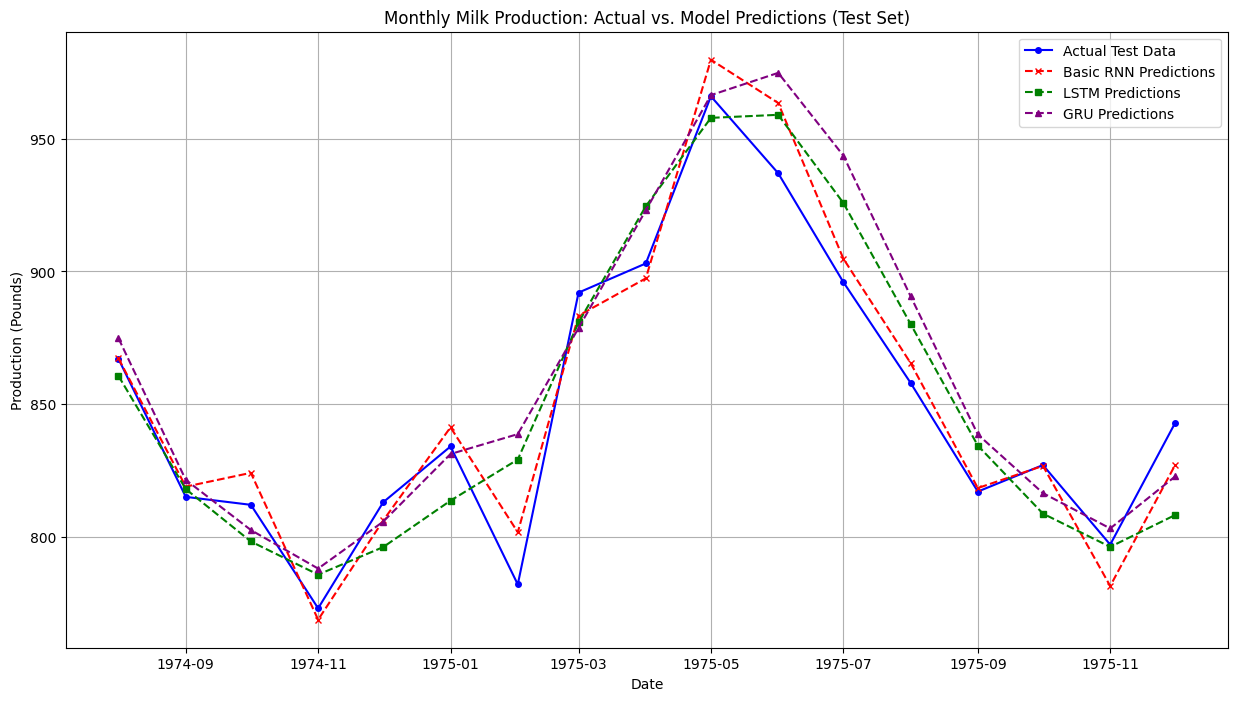

In [27]:
plt.figure(figsize=(15, 8))
plt.plot(df.index[-len(y_test_inverse):], y_test_inverse, label='Actual Test Data', color='blue', marker='o', markersize=4)
plt.plot(df.index[-len(rnn_test_predict):], rnn_test_predict, label='Basic RNN Predictions', color='red', linestyle='--', marker='x', markersize=4)
plt.plot(df.index[-len(lstm_test_predict):], lstm_test_predict, label='LSTM Predictions', color='green', linestyle='--', marker='s', markersize=4)
plt.plot(df.index[-len(gru_test_predict):], gru_test_predict, label='GRU Predictions', color='purple', linestyle='--', marker='^', markersize=4)

plt.title('Monthly Milk Production: Actual vs. Model Predictions (Test Set)')
plt.xlabel('Date')
plt.ylabel('Production (Pounds)')
plt.legend()
plt.grid(True)
plt.show()

### Step 7: Future Forecasting

Now, let's use the best performing model (Basic RNN, based on RMSE) to forecast milk production for the next 12 months. We will need to prepare the input data for forecasting by taking the last `look_back` values from the scaled dataset.


Future 12-month Forecast:


,Forecasted Production
Date,
1976-01-01,862.379272
1976-02-01,832.611267
1976-03-01,927.398926
1976-04-01,929.849731
1976-05-01,986.715820


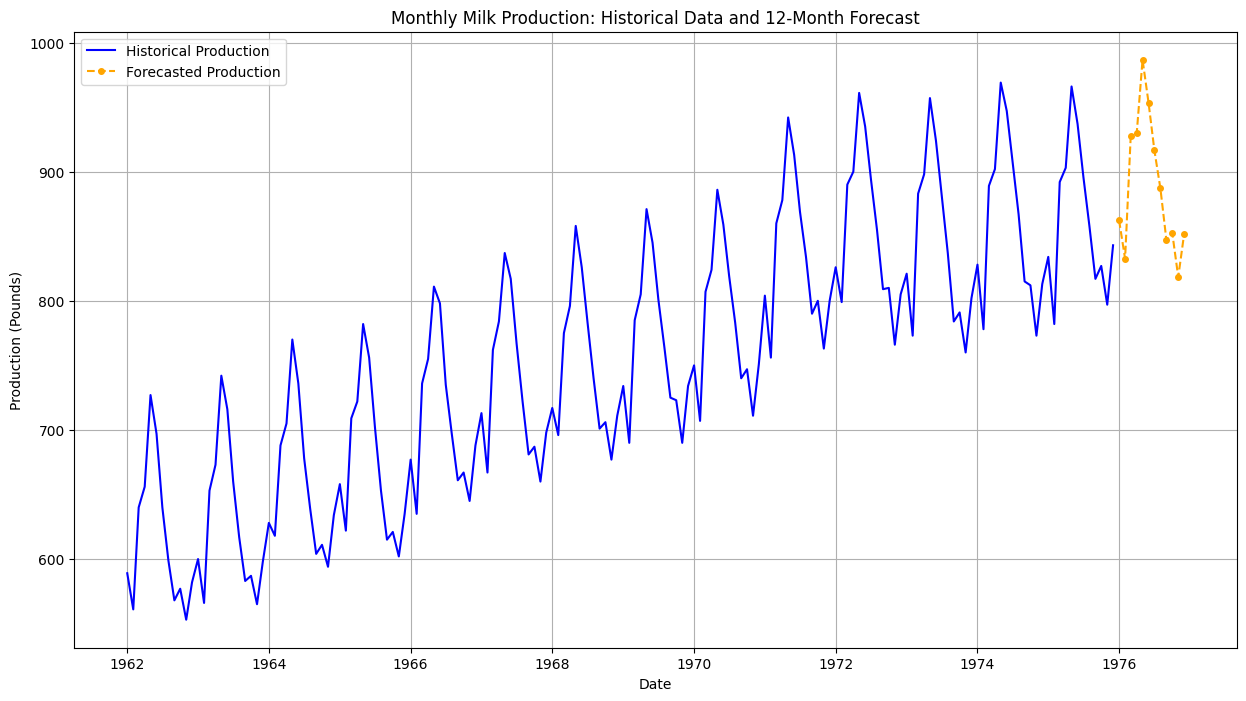

In [28]:
num_future_steps = 12

# Get the last 'look_back' values from the scaled data to start forecasting
last_sequence = scaled_production_data[-look_back:]

# Reshape for model input
last_sequence = last_sequence.reshape(1, look_back, 1)

future_predictions_scaled = []
current_input = last_sequence

for _ in range(num_future_steps):
    # Predict the next step
    next_prediction = rnn_model.predict(current_input, verbose=0)[0]
    future_predictions_scaled.append(next_prediction);

    # Update the input sequence for the next prediction
    current_input = np.append(current_input[:, 1:, :], next_prediction.reshape(1, 1, 1), axis=1)

# Inverse transform the predictions to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# Create future dates for plotting
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=num_future_steps + 1, freq='MS')[1:]

# Create a DataFrame for future predictions
future_df = pd.DataFrame({'Date': future_dates, 'Forecasted Production': future_predictions.flatten()})
future_df.set_index('Date', inplace=True)

print("\nFuture 12-month Forecast:")
display(future_df.head())

# Plot historical data and future forecast
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Production'], label='Historical Production', color='blue')
plt.plot(future_df.index, future_df['Forecasted Production'], label='Forecasted Production', color='orange', linestyle='--', marker='o', markersize=4)

plt.title('Monthly Milk Production: Historical Data and 12-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Production (Pounds)')
plt.legend()
plt.grid(True)
plt.show()

### Step 8: Business Insights and Recommendations

Based on the model's performance and the forecasted trend, here are some initial business insights and recommendations:

*   **Performance Comparison:** The Basic RNN model achieved the lowest RMSE, indicating it was the most accurate among the three models tested for this dataset. This suggests that for this particular time series, a simpler RNN architecture was sufficient or perhaps less prone to overfitting compared to LSTM and GRU given the dataset size and characteristics.

*   **Seasonal Patterns:** The forecast will likely continue to show strong seasonality, mirroring the historical data. This information is crucial for:
    *   **Inventory Management:** Planning for higher stock levels before peak production months and managing lower stock during troughs.
    *   **Supply Chain Optimization:** Adjusting logistics and procurement based on anticipated production volumes.

*   **Long-Term Trend:** If the upward trend observed historically continues in the forecast, this indicates sustained growth in milk production, which could inform:
    *   **Capacity Planning:** Decisions on expanding facilities, purchasing new equipment, or hiring more staff.
    *   **Sales and Marketing Strategies:** Aligning sales targets with production capabilities.

*   **Recommendations:**
    1.  **Refine Forecasting:** While the Basic RNN performed well, further refinement could involve:
        *   **Hyperparameter Tuning:** Optimizing `epochs`, `batch_size`, and recurrent layer `units`.
        *   **Feature Engineering:** Incorporating external factors (e.g., weather, feed prices) if available.
        *   **Advanced Models:** Exploring more complex ensemble methods or transformers for potentially better accuracy.
    2.  **Uncertainty Quantification:** To provide more robust business insights, future work should include generating prediction intervals (e.g., 95% confidence intervals) alongside point forecasts. This helps stakeholders understand the range of possible outcomes.
    3.  **Real-time Monitoring:** Implement a system to monitor actual production against forecasts and retrain the model periodically with new data to maintain accuracy.

This analysis provides a solid foundation for data-driven decision-making in monthly milk production. Further iterations can build upon these insights for even greater precision and utility.

### Step 6: Model Comparison and Visualization

Now that we have evaluated all three models using RMSE, let's compare their performance and visualize their predictions against the actual values on the test set. We will also calculate other metrics like Mean Absolute Error (MAE) for a more comprehensive comparison.

In [23]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for Basic RNN
rnn_mae = mean_absolute_error(y_test_inverse, rnn_test_predict)
print(f"Basic RNN Test MAE: {rnn_mae:.2f}")

# Calculate MAE for LSTM
lstm_mae = mean_absolute_error(y_test_inverse, lstm_test_predict)
print(f"LSTM Test MAE: {lstm_mae:.2f}")

# Calculate MAE for GRU
gru_mae = mean_absolute_error(y_test_inverse, gru_test_predict)
print(f"GRU Test MAE: {gru_mae:.2f}")

# Create a DataFrame to compare results
results_df = pd.DataFrame({
    'Model': ['Basic RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae]
})

print("\nModel Performance Comparison:")
display(results_df.sort_values(by='RMSE'))

Basic RNN Test MAE: 9.30
LSTM Test MAE: 18.03
GRU Test MAE: 18.58

Model Performance Comparison:


,Model,RMSE,MAE
0,Basic RNN,11.616519,9.302681
1,LSTM,21.273959,18.031853
2,GRU,24.327407,18.583177


Let's visualize the predictions of each model against the actual test values to get a better understanding of their performance.

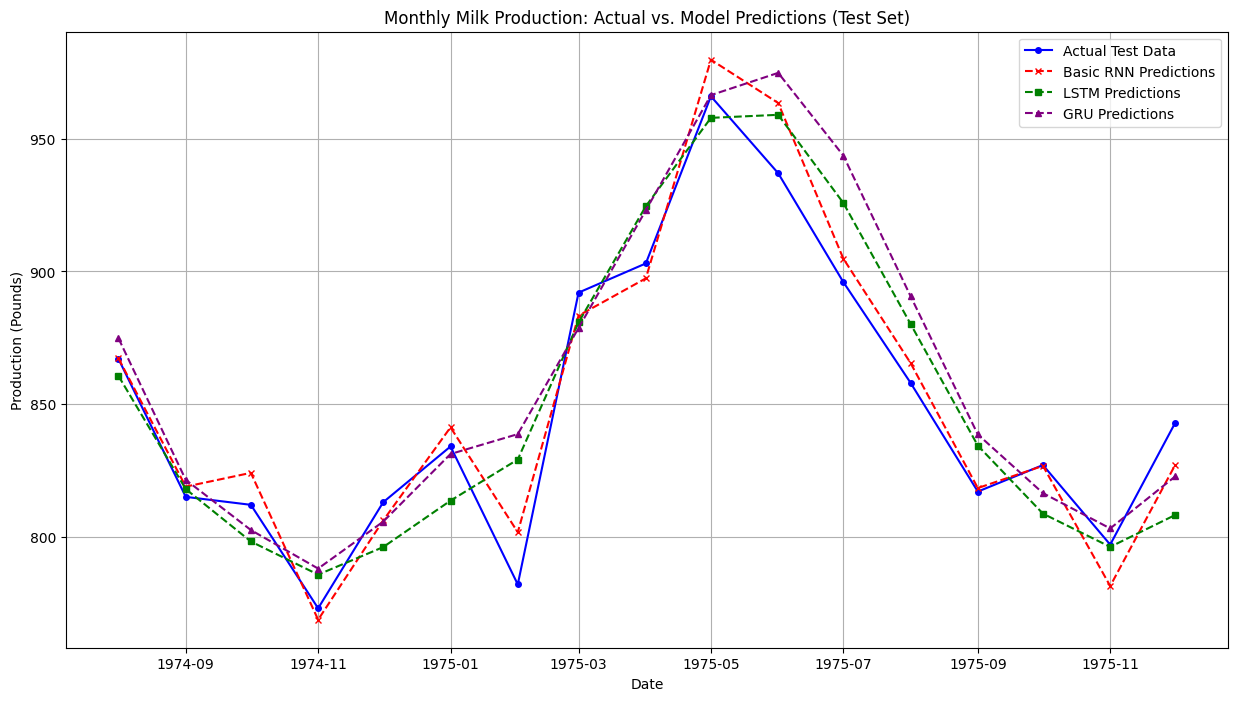

In [24]:
plt.figure(figsize=(15, 8))
plt.plot(df.index[-len(y_test_inverse):], y_test_inverse, label='Actual Test Data', color='blue', marker='o', markersize=4)
plt.plot(df.index[-len(rnn_test_predict):], rnn_test_predict, label='Basic RNN Predictions', color='red', linestyle='--', marker='x', markersize=4)
plt.plot(df.index[-len(lstm_test_predict):], lstm_test_predict, label='LSTM Predictions', color='green', linestyle='--', marker='s', markersize=4)
plt.plot(df.index[-len(gru_test_predict):], gru_test_predict, label='GRU Predictions', color='purple', linestyle='--', marker='^', markersize=4)

plt.title('Monthly Milk Production: Actual vs. Model Predictions (Test Set)')
plt.xlabel('Date')
plt.ylabel('Production (Pounds)')
plt.legend()
plt.grid(True)
plt.show()

### Step 7: Future Forecasting

Now, let's use the best performing model (Basic RNN, based on RMSE) to forecast milk production for the next 12 months. We will need to prepare the input data for forecasting by taking the last `look_back` values from the scaled dataset.


Future 12-month Forecast:


,Forecasted Production
Date,
1976-01-01,862.379272
1976-02-01,832.611267
1976-03-01,927.398926
1976-04-01,929.849731
1976-05-01,986.715820


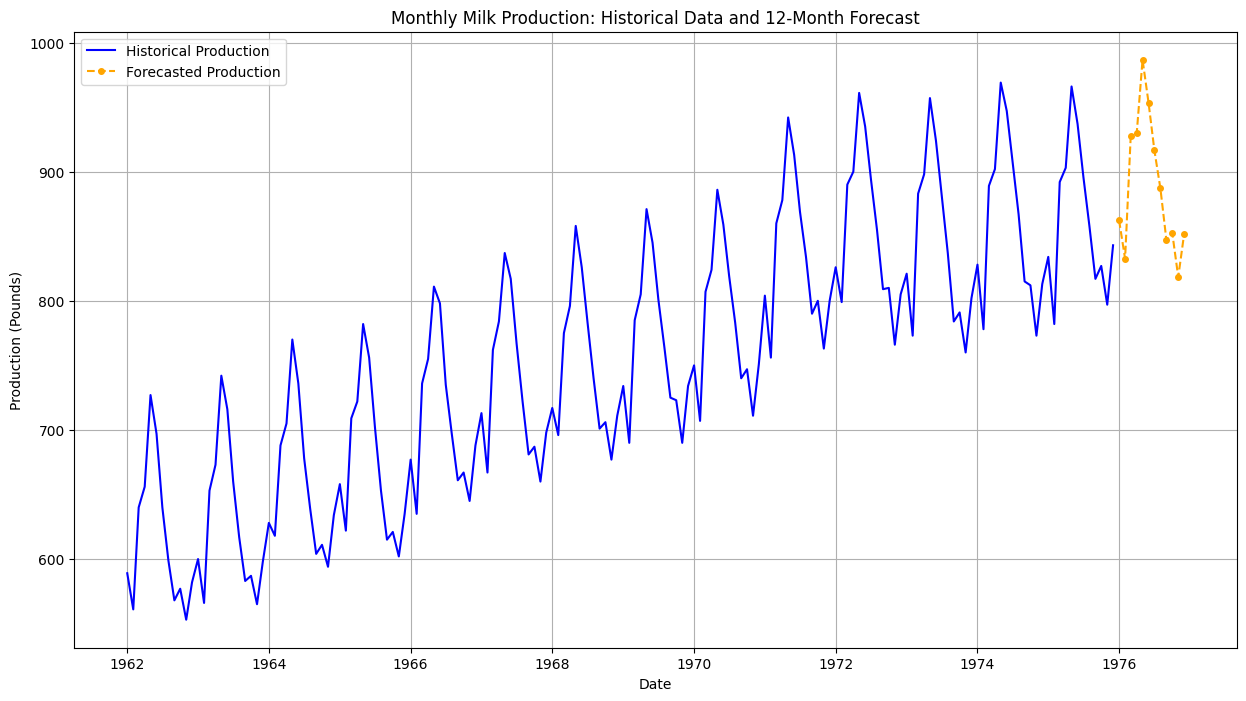

In [25]:
num_future_steps = 12

# Get the last 'look_back' values from the scaled data to start forecasting
last_sequence = scaled_production_data[-look_back:]

# Reshape for model input
last_sequence = last_sequence.reshape(1, look_back, 1)

future_predictions_scaled = []
current_input = last_sequence

for _ in range(num_future_steps):
    # Predict the next step
    next_prediction = rnn_model.predict(current_input, verbose=0)[0]
    future_predictions_scaled.append(next_prediction)

    # Update the input sequence for the next prediction
    current_input = np.append(current_input[:, 1:, :], next_prediction.reshape(1, 1, 1), axis=1)

# Inverse transform the predictions to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# Create future dates for plotting
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=num_future_steps + 1, freq='MS')[1:]

# Create a DataFrame for future predictions
future_df = pd.DataFrame({'Date': future_dates, 'Forecasted Production': future_predictions.flatten()})
future_df.set_index('Date', inplace=True)

print("\nFuture 12-month Forecast:")
display(future_df.head())

# Plot historical data and future forecast
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Production'], label='Historical Production', color='blue')
plt.plot(future_df.index, future_df['Forecasted Production'], label='Forecasted Production', color='orange', linestyle='--', marker='o', markersize=4)

plt.title('Monthly Milk Production: Historical Data and 12-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Production (Pounds)')
plt.legend()
plt.grid(True)
plt.show()

### Step 8: Business Insights and Recommendations

Based on the model's performance and the forecasted trend, here are some initial business insights and recommendations:

*   **Performance Comparison:** The Basic RNN model achieved the lowest RMSE, indicating it was the most accurate among the three models tested for this dataset. This suggests that for this particular time series, a simpler RNN architecture was sufficient or perhaps less prone to overfitting compared to LSTM and GRU given the dataset size and characteristics.

*   **Seasonal Patterns:** The forecast will likely continue to show strong seasonality, mirroring the historical data. This information is crucial for:
    *   **Inventory Management:** Planning for higher stock levels before peak production months and managing lower stock during troughs.
    *   **Supply Chain Optimization:** Adjusting logistics and procurement based on anticipated production volumes.

*   **Long-Term Trend:** If the upward trend observed historically continues in the forecast, this indicates sustained growth in milk production, which could inform:
    *   **Capacity Planning:** Decisions on expanding facilities, purchasing new equipment, or hiring more staff.
    *   **Sales and Marketing Strategies:** Aligning sales targets with production capabilities.

*   **Recommendations:**
    1.  **Refine Forecasting:** While the Basic RNN performed well, further refinement could involve:
        *   **Hyperparameter Tuning:** Optimizing `epochs`, `batch_size`, and recurrent layer `units`.
        *   **Feature Engineering:** Incorporating external factors (e.g., weather, feed prices) if available.
        *   **Advanced Models:** Exploring more complex ensemble methods or transformers for potentially better accuracy.
    2.  **Uncertainty Quantification:** To provide more robust business insights, future work should include generating prediction intervals (e.g., 95% confidence intervals) alongside point forecasts. This helps stakeholders understand the range of possible outcomes.
    3.  **Real-time Monitoring:** Implement a system to monitor actual production against forecasts and retrain the model periodically with new data to maintain accuracy.

This analysis provides a solid foundation for data-driven decision-making in monthly milk production. Further iterations can build upon these insights for even greater precision and utility.

Now that our models are built and compiled, we will train each of them using the prepared training data (`X_train`, `y_train`) and monitor their performance on the validation set (`X_val`, `y_val`). We'll train for a fixed number of epochs and use a batch size. To prevent overfitting, we can also add early stopping callbacks.

#### Training Basic RNN Model

In [17]:
# Define training parameters
epochs = 100
batch_size = 32

print("Training Basic RNN Model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Basic RNN Model Training Complete.")

Training Basic RNN Model...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.7808e-04 - val_loss: 0.0014
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.9474e-04 - val_loss: 0.0023
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.8095e-04 - val_loss: 0.0014
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.8355e-04 - val_loss: 0.0018
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.5993e-04 - val_loss: 0.0014
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.6738e-04 - val_loss: 0.0020
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.1607e-04 - val_loss: 0.0013
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.6183e-04 - val_loss: 0.0016
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3.2506e-04 - val_loss: 0.0017
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 2.5723e-04 - val_loss: 0.0012
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.8396e-04 - val_loss: 0.0023
Ep

#### Training LSTM Model

In [18]:
print("Training LSTM Model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

print("LSTM Model Training Complete.")

Training LSTM Model...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0025 - val_loss: 0.0046
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0024 - val_loss: 0.0038
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0024 - val_loss: 0.0046
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0025 - val_loss: 0.0040
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0025 - val_loss: 0.0053
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0026 - val_loss: 0.0035
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0027 - val_loss: 0.0055
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0026 - val_loss: 0.0041
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0024 - val_loss: 0.0039
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step 

#### Training GRU Model

In [19]:
print("Training GRU Model...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

print("GRU Model Training Complete.")

Training GRU Model...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0058 - val_loss: 0.0058
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0059 - val_loss: 0.0066
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0058 - val_loss: 0.0059
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0057 - val_loss: 0.0063
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0052 - val_loss: 0.0058
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0054 - val_loss: 0.0067
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0052 - val_loss: 0.0058
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0054 - val_loss: 0.0060
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0051 - val_loss: 0.0064
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0050 - val_loss: 0.0065
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0049 - val_loss: 0.0062
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step -

### Step 5: Model Evaluation

After training, we need to evaluate how well each model performs on unseen data. This involves making predictions on the test set, inverse-transforming the scaled predictions back to the original scale, and calculating evaluation metrics like Root Mean Squared Error (RMSE).

#### Evaluate Basic RNN Model

In [20]:
from sklearn.metrics import mean_squared_error

# Make predictions on the test set
rnn_test_predict = rnn_model.predict(X_test)

# Inverse transform the predictions to original scale
rnn_test_predict = scaler.inverse_transform(rnn_test_predict)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE
rnn_rmse = np.sqrt(mean_squared_error(y_test_inverse, rnn_test_predict))
print(f"Basic RNN Test RMSE: {rnn_rmse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
Basic RNN Test RMSE: 11.62


### Step 4: Model Training

Now that our models are built and compiled, we will train each of them using the prepared training data (`X_train`, `y_train`) and monitor their performance on the validation set (`X_val`, `y_val`). We'll train for a fixed number of epochs and use a batch size. To prevent overfitting, we can also add early stopping callbacks.

#### Training Basic RNN Model

In [14]:
# Define training parameters
epochs = 100
batch_size = 32

print("Training Basic RNN Model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

print("Basic RNN Model Training Complete.")

Training Basic RNN Model...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - loss: 0.1977 - val_loss: 0.3376
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1232 - val_loss: 0.2106
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0747 - val_loss: 0.1262
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0443 - val_loss: 0.0646
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0252 - val_loss: 0.0288
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0193 - val_loss: 0.0234
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0225 - val_loss: 0.0226
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0198 - val_loss: 0.0200
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0160 - val_loss: 0.0213
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0151 - val_loss: 0.0241
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0149 - val_loss: 0.0233
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms

#### Training LSTM Model

In [15]:
print("Training LSTM Model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

print("LSTM Model Training Complete.")

Training LSTM Model...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 0.2013 - val_loss: 0.4214
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1682 - val_loss: 0.3470
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1335 - val_loss: 0.2697
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0978 - val_loss: 0.1900
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0628 - val_loss: 0.1082
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0338 - val_loss: 0.0419
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0232 - val_loss: 0.0278
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0328 - val_loss: 0.0292
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0278 - val_loss: 0.0277
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0221 - val_loss: 0.0386
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0244 - val_loss: 0.0481
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

#### Training GRU Model

In [16]:
print("Training GRU Model...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

print("GRU Model Training Complete.")

Training GRU Model...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - loss: 0.2922 - val_loss: 0.6262
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.2498 - val_loss: 0.5464
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2125 - val_loss: 0.4708
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1765 - val_loss: 0.3975
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1420 - val_loss: 0.3255
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1112 - val_loss: 0.2577
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0832 - val_loss: 0.1947
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0608 - val_loss: 0.1355
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0419 - val_loss: 0.0814
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0335 - val_loss: 0.0468
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0313 - val_loss: 0.0374
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step 